# Proyecto Deep Learning - **SUDOKU**

### Importar librerías

In [1]:
import numpy as np
import pandas as pd

# Visualizaciones
import matplotlib.pyplot as plt

import cv2
from pathlib import Path

# Redes
from ultralytics import YOLO

## 1. Detección del tablero

### 1.1. Definir rutas

In [2]:
# Definir root
PROJECT_ROOT = Path("..")

# Path a modelo e imagen
YOLO_MODEL_PATH = PROJECT_ROOT / "models" / "best.pt"
IMAGE_PATH = PROJECT_ROOT / "data" / "img.png"

# Folder de salidas
OUTPUT_DIR = Path("outputs")
CELLS_DIR = OUTPUT_DIR / "cells"

#OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
#CELLS_DIR.mkdir(parents=True, exist_ok=True)

### 1.2. Cargar modelo YOLO

In [3]:
# From "Deteccion_YOLO_used.ipynb"
modelo_yolo = YOLO(YOLO_MODEL_PATH)

print("Modelo YOLO cargado correctamente")
print("Clases del modelo:", modelo_yolo.names)

Modelo YOLO cargado correctamente
Clases del modelo: {0: 'sudoku'}


### 1.3. Cargar y visualizar la imagen

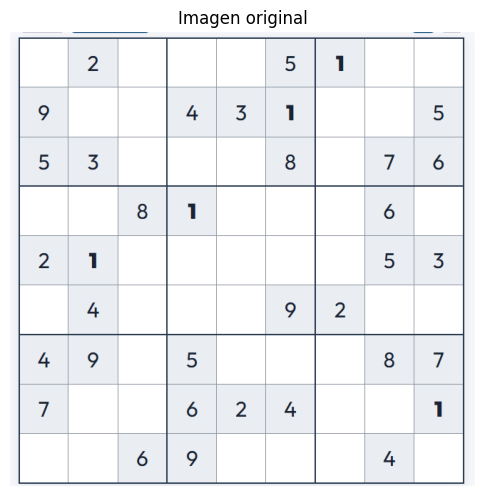

In [4]:
# Leer la imagen de prueba y mostrarla. 
# OpenCV carga imágenes en formato BGR, pero matplotlib espera RGB, hay que convertir el color antes de visualizar.

# Cargar imagen (bgr)
image_bgr = cv2.imread(str(IMAGE_PATH))

if image_bgr is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {IMAGE_PATH}")

# Imagen a rgb
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Visualizar imagen (rgb)
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Imagen original")
plt.show()

### 1.4. Detectar tablero con YOLO


image 1/1 d:\BOOTCAMP\CARPETA_BARBARA\SUDOKU\SUDOKU\notebooks\..\data\img.png: 640x640 1 sudoku, 283.3ms
Speed: 10.3ms preprocess, 283.3ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)


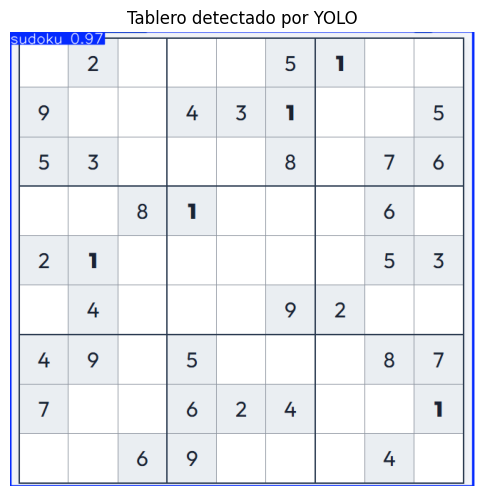

Tablero recortado guardado en: outputs\imagen_anotada_yolo.png


In [5]:
# From "Deteccion_YOLO_used.ipynb"
resultados = modelo_yolo(str(IMAGE_PATH))
resultado = resultados[0]

imagen_anotada = resultado.plot()

# Visualizar imagen detectada por YOLO
plt.figure(figsize=(6, 6))
plt.imshow(imagen_anotada[:, :, ::-1])
plt.axis("off")
plt.title("Tablero detectado por YOLO")
plt.show()

# Guardar tablero detectado por YOLO
imagen_anotada_path = OUTPUT_DIR / "imagen_anotada_yolo.png"
cv2.imwrite(str(imagen_anotada_path), imagen_anotada)

print(f"Tablero recortado guardado en: {imagen_anotada_path}")

### 1.5. Inspeccionar cajas detectadas y seleccionar la mejor

In [6]:
# From "Deteccion_YOLO_used.ipynb"
# Mostrar clase, confianza y coordenadas de la caja detectadas por YOLO.

cajas = resultado.boxes

print(f"Se han detectado {len(cajas)} objetos:\n")

for caja in cajas:
    clase_id = int(caja.cls[0])
    nombre = modelo_yolo.names[clase_id]
    confianza = float(caja.conf[0])
    x1, y1, x2, y2 = caja.xyxy[0].tolist()

    print(
        f"{nombre:12s} | confianza: {confianza:.2%} | "
        f"caja: ({x1:.0f}, {y1:.0f}) - ({x2:.0f}, {y2:.0f})"
    )

Se han detectado 1 objetos:

sudoku       | confianza: 96.67% | caja: (0, 0) - (649, 637)


#### 1.5.1. Seleccionar la mejor caja

In [7]:
# Si hubiera más de de una caja, seleccionar la de mayor confianza (caja del tablero)

def get_best_box(result):
    boxes = result.boxes

    if len(boxes) == 0:
        raise ValueError("YOLO no detectó ningún tablero.")

    best_box = max(boxes, key=lambda box: float(box.conf[0]))

    x1, y1, x2, y2 = best_box.xyxy[0].tolist()
    confidence = float(best_box.conf[0])
    class_id = int(best_box.cls[0])

    return {
        "x1": int(x1),
        "y1": int(y1),
        "x2": int(x2),
        "y2": int(y2),
        "confidence": confidence,
        "class_id": class_id,
    }


In [8]:
best_box = get_best_box(resultado)
best_box

{'x1': 0,
 'y1': 0,
 'x2': 649,
 'y2': 637,
 'confidence': 0.9666802883148193,
 'class_id': 0}

### 1.6. Recortar y guardar el tablero detectado

In [9]:
def crop_board_from_box(image_bgr, box, padding=7):
    h, w = image_bgr.shape[:2]

    x1 = max(box["x1"] - padding, 0)
    y1 = max(box["y1"] - padding, 0)
    x2 = min(box["x2"] + padding, w)
    y2 = min(box["y2"] + padding, h)

    cropped = image_bgr[y1:y2, x1:x2]

    return cropped

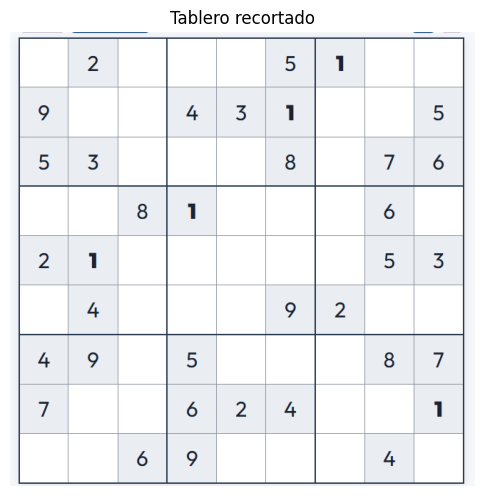

Dimensiones del tablero recortado: (637, 652, 3)
Tablero recortado guardado en: outputs\cropped_board.png


In [10]:
board_bgr = crop_board_from_box(image_bgr, best_box, padding=7)
board_rgb = cv2.cvtColor(board_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(board_rgb)
plt.axis("off")
plt.title("Tablero recortado")
plt.show()

print("Dimensiones del tablero recortado:", board_bgr.shape)

# Guardar el tablero recortado
cropped_board_path = OUTPUT_DIR / "cropped_board.png"
cv2.imwrite(str(cropped_board_path), board_bgr)

print(f"Tablero recortado guardado en: {cropped_board_path}")

## 2. Dividir el tablero en 81 celdas

### 2.1. Redimensionar el tablero a tamaño cuadrado

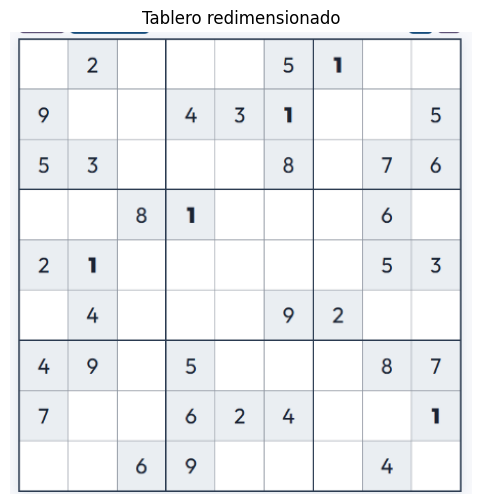

Tamaño tablero: (450, 450, 3)
Tamaño celda: 50
Tablero recortado guardado en: outputs\resized_board.png


In [11]:
BOARD_SIZE = 450
CELL_SIZE = BOARD_SIZE // 9

board_resized = cv2.resize(board_bgr, (BOARD_SIZE, BOARD_SIZE))

board_resized_rgb = cv2.cvtColor(board_resized, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(board_resized_rgb)
plt.axis("off")
plt.title("Tablero redimensionado")
plt.show()

print("Tamaño tablero:", board_resized.shape)
print("Tamaño celda:", CELL_SIZE)

# Guardar el tablero redimensionado
resized_board_path = OUTPUT_DIR / "resized_board.png"
cv2.imwrite(str(resized_board_path), board_resized)

print(f"Tablero recortado guardado en: {resized_board_path}")

### 2.2. Dividir en celdas

Recorre las 9 filas y 9 columnas del tablero. Para cada posición, recorta una celda.
- La celda (0, 0) es la esquina superior izquierda.
- La celda (8, 8) es la esquina inferior derecha.

In [12]:
def split_board_into_cells(board_image, board_size=450):
    cell_size = board_size // 9
    cells = []

    for row in range(9):
        row_cells = []

        for col in range(9):
            y1 = row * cell_size
            y2 = (row + 1) * cell_size
            x1 = col * cell_size
            x2 = (col + 1) * cell_size

            cell = board_image[y1:y2, x1:x2]
            row_cells.append(cell)

        cells.append(row_cells)

    return cells

In [13]:
cells = split_board_into_cells(board_resized, BOARD_SIZE)

print("Número de filas:", len(cells))
print("Número de columnas en la primera fila:", len(cells[0]))
print("Tamaño de una celda:", cells[0][0].shape)

Número de filas: 9
Número de columnas en la primera fila: 9
Tamaño de una celda: (50, 50, 3)


### 2.3. Visualizar las 81 celdas

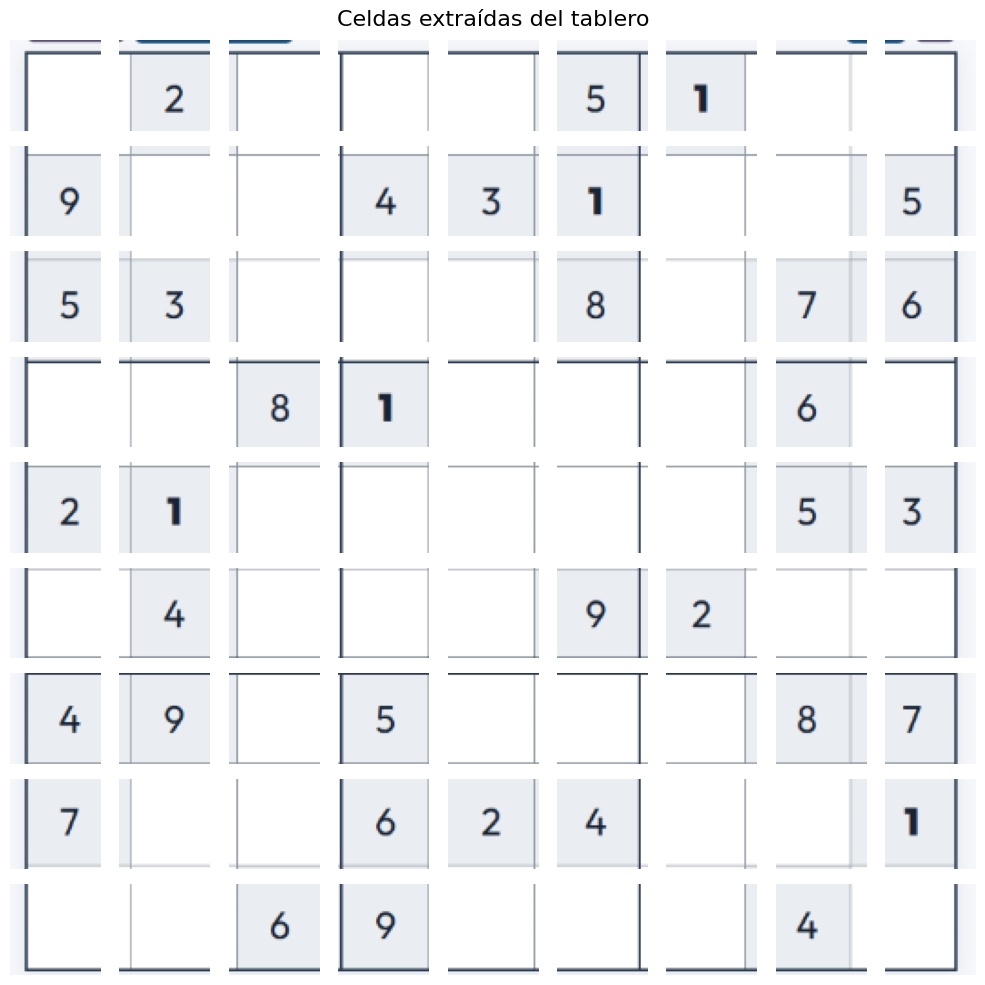

Tablero celdas extraídas guardado en: outputs\extracted_board.png


In [14]:
fig, axes = plt.subplots(9, 9, figsize=(10, 10))

for row in range(9):
    for col in range(9):
        cell_rgb = cv2.cvtColor(cells[row][col], cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(cell_rgb)
        axes[row, col].axis("off")

plt.suptitle("Celdas extraídas del tablero", fontsize=16)
plt.tight_layout()

# Guardar celdas extraídas
cell_rgb_path = OUTPUT_DIR / "extracted_board.png"
plt.savefig(cell_rgb_path, dpi=300, bbox_inches="tight")

plt.show()
print(f"Tablero celdas extraídas guardado en: {cell_rgb_path}")

### 2.4. Guardar las celdas (individualmente)

In [15]:
for row in range(9):
    for col in range(9):
        cell_path = CELLS_DIR / f"cell_{row}_{col}.png"
        cv2.imwrite(str(cell_path), cells[row][col])

print(f"Celdas guardadas en: {CELLS_DIR}")

Celdas guardadas en: outputs\cells


## 3. Limpiar celdas y quitar bordes

### 3.1. Recortar margen interno de cada celda

Eliminar líneas del tablero quitando los bordes de la celda recortando un pequeño margen por dentro. Quita 5 pixels por cada lado (de cada celda que mide 50x50).

In [16]:
# Función para recortar bordes
def crop_cell_margin(cell, margin=5):
    h, w = cell.shape[:2]
    return cell[margin:h-margin, margin:w-margin]

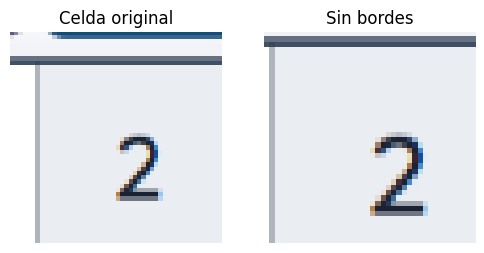

In [17]:
# Probar la función
example_cell = cells[0][1]  # aquí debería estar el número 2
example_crop = crop_cell_margin(example_cell, margin=5)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(cv2.cvtColor(example_cell, cv2.COLOR_BGR2RGB))
axes[0].set_title("Celda original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(example_crop, cv2.COLOR_BGR2RGB))
axes[1].set_title("Sin bordes")
axes[1].axis("off")

plt.show()

### 3.2. Preprocesar celda para detectar contenido

Convertir la celda a **escala de grises**. Aplica un *threshold* e invierte los colores para que el número quede blanco sobre fondo negro. (Simular el formato *MNIST*).

In [18]:
# Función para detectar contenido
def preprocess_cell_for_digit(cell, margin=5):
    # 1. Quitar bordes de la celda
    cell_crop = crop_cell_margin(cell, margin=margin)

    # 2. Convertir a escala de grises
    gray = cv2.cvtColor(cell_crop, cv2.COLOR_BGR2GRAY)

    # 3. Suavizar un poco para reducir ruido
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    # 4. Threshold inverso:
    #    fondo claro -> negro
    #    número oscuro -> blanco
    thresh = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    return thresh

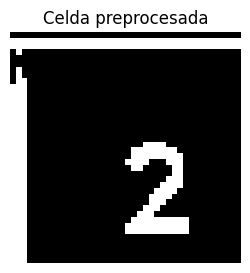

In [19]:
# Probar la función - celda con contenido
processed_cell = preprocess_cell_for_digit(cells[0][1], margin=5)

plt.figure(figsize=(3, 3))
plt.imshow(processed_cell, cmap="gray")
plt.axis("off")
plt.title("Celda preprocesada")
plt.show()

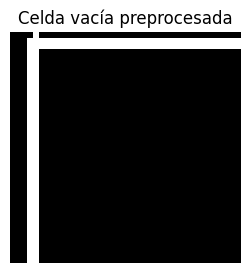

In [20]:
# Probar la función - celda vacía
empty_cell = preprocess_cell_for_digit(cells[0][0], margin=5)

plt.figure(figsize=(3, 3))
plt.imshow(empty_cell, cmap="gray")
plt.axis("off")
plt.title("Celda vacía preprocesada")
plt.show()

### 3.3. Detectar si una celda está vacía

In [21]:
# Función para detectar una celda vacía
def is_empty_cell(processed_cell, threshold=25):
    white_pixels = cv2.countNonZero(processed_cell)
    return white_pixels < threshold

In [22]:
# Probar la función - ¿celda vacía?
cell_with_digit = preprocess_cell_for_digit(cells[0][1], margin=5)
cell_empty = preprocess_cell_for_digit(cells[0][0], margin=5)

print("Píxeles blancos celda con número:", cv2.countNonZero(cell_with_digit))
print("¿Celda con número está vacía?", is_empty_cell(cell_with_digit))

print("Píxeles blancos celda vacía:", cv2.countNonZero(cell_empty))
print("¿Celda vacía está vacía?", is_empty_cell(cell_empty))

Píxeles blancos celda con número: 268
¿Celda con número está vacía? False
Píxeles blancos celda vacía: 149
¿Celda vacía está vacía? False


### 3.4. Visualizar celdas preprocesadas

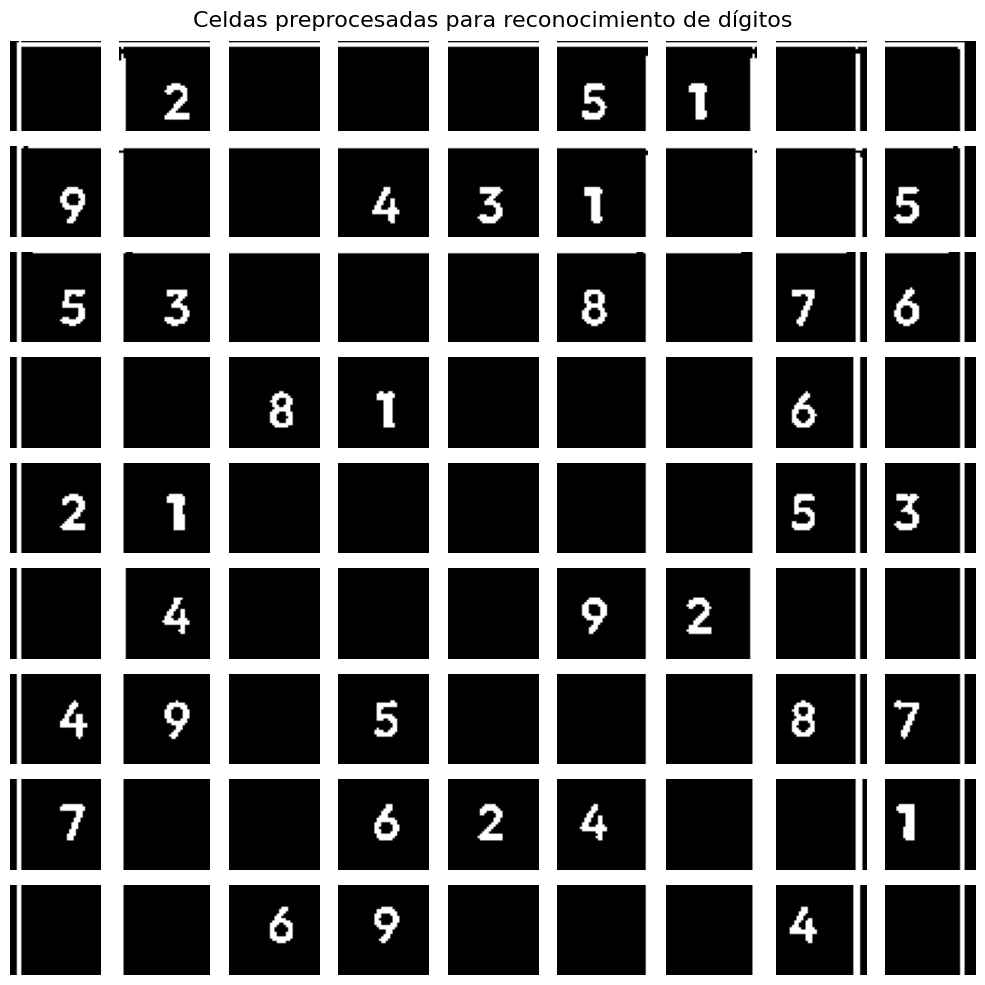

Tablero procesado para reconocimiento de dígitos guardado en: outputs\processed_bw_board.png


In [23]:
# Corroborar si los números quedan blancos sobre fondo negro y si las celdas vacías quedan casi negras
fig, axes = plt.subplots(9, 9, figsize=(10, 10))

for row in range(9):
    for col in range(9):
        processed = preprocess_cell_for_digit(cells[row][col], margin=5)
        axes[row, col].imshow(processed, cmap="gray")
        axes[row, col].axis("off")

plt.suptitle("Celdas preprocesadas para reconocimiento de dígitos", fontsize=16)
plt.tight_layout()

# Guardar celdas extraídas
processed_path = OUTPUT_DIR / "processed_bw_board.png"
plt.savefig(processed_path, dpi=300, bbox_inches="tight")

plt.show()
print(f"Tablero procesado para reconocimiento de dígitos guardado en: {processed_path}")

### 3.5. Ajustar margen interno

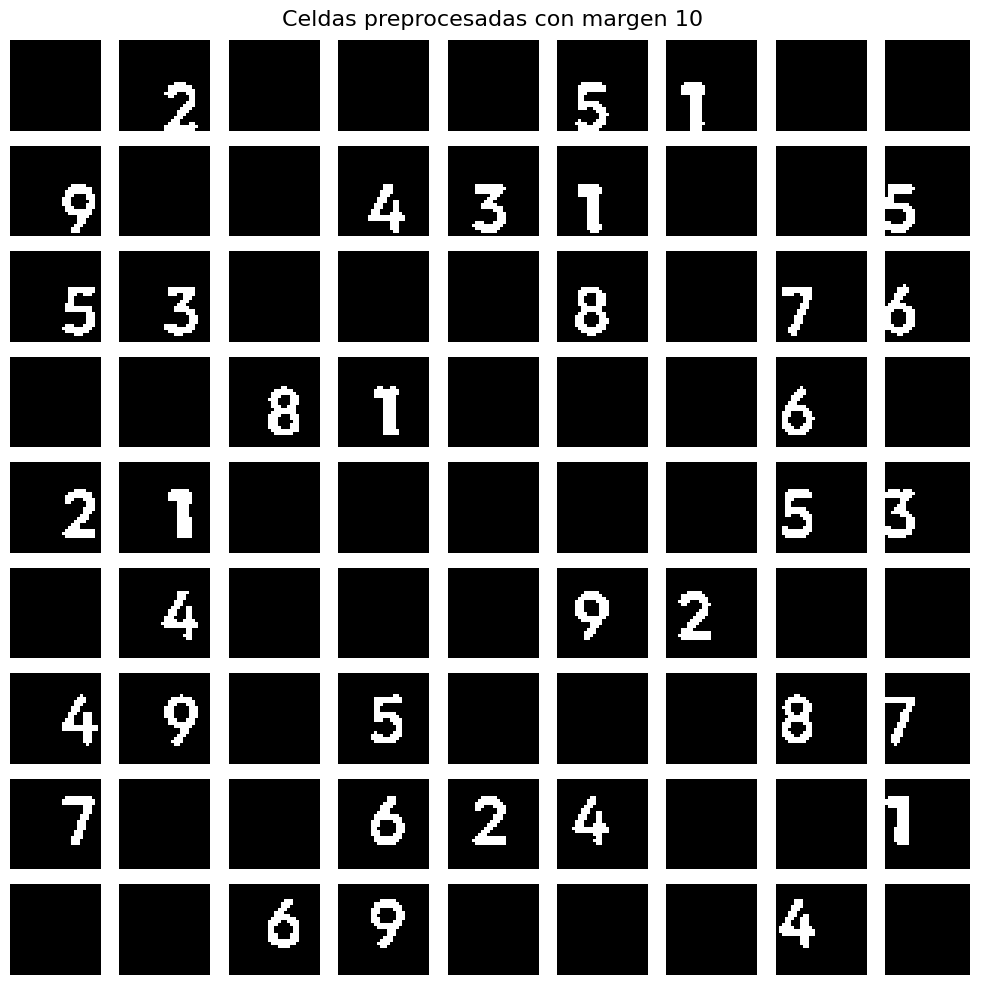

Tablero celdas procesadas con margen 10 guardado en: outputs\mnist_cells_clean.png


In [24]:
fig, axes = plt.subplots(9, 9, figsize=(10, 10))

for row in range(9):
    for col in range(9):
        processed = preprocess_cell_for_digit(cells[row][col], margin=10)
        axes[row, col].imshow(processed, cmap="gray")
        axes[row, col].axis("off")

plt.suptitle("Celdas preprocesadas con margen 10", fontsize=16)
plt.tight_layout()

# Guardar celdas extraídas (margen 10)
processed_path = OUTPUT_DIR / "processed_bw_board_10.png"
plt.savefig(processed_path, dpi=300, bbox_inches="tight")

mnist_cells_clean_path = OUTPUT_DIR / "mnist_cells_clean.png"
plt.savefig(mnist_cells_clean_path, dpi=300, bbox_inches="tight")


plt.show()
print(f"Tablero celdas procesadas con margen 10 guardado en: {mnist_cells_clean_path}")

## 4. Detectar celdas vacías

Identificar qué celdas tienen número y cuáles no. 
- Si la celda está vacía, se agrega un 0 en la matriz.
- Si la celta tiene número, se pasa a MNIST/CNN.

### 4.1. Contar número de píxeles blancos

- Una celda vacía debería tener muy pocos píxeles blancos.
- Una celda con número debería tener bastantes más.

In [25]:
white_pixel_counts = []

for row in range(9):
    row_counts = []

    for col in range(9):
        processed = preprocess_cell_for_digit(cells[row][col], margin=10)
        white_pixels = cv2.countNonZero(processed)
        row_counts.append(white_pixels)

    white_pixel_counts.append(row_counts)

white_pixel_counts = np.array(white_pixel_counts)

white_pixel_counts

array([[  0,  85,   0,   0,   0,  89,  79,   0,  60],
       [ 87,   0,   0,  78,  91,  79,   0,   0, 151],
       [ 89,  86,   0,   0,   0,  99,   0,  66, 145],
       [  0,   0, 100,  77,   0,   0,   0,  82,  60],
       [ 92,  86,   0,   0,   0,   0,   0,  91, 146],
       [  0,  76,   0,   0,   0,  88,  93,   0,  60],
       [ 78,  86,   0,  84,   0,   0,   0,  96, 120],
       [ 71,   0,   0,  90,  88,  74,   0,   0, 143],
       [  0,   0,  85,  86,   0,   0,   0,  81,  60]])

#### 4.1.1. Visualizar conteos

In [26]:
print(white_pixel_counts)

[[  0  85   0   0   0  89  79   0  60]
 [ 87   0   0  78  91  79   0   0 151]
 [ 89  86   0   0   0  99   0  66 145]
 [  0   0 100  77   0   0   0  82  60]
 [ 92  86   0   0   0   0   0  91 146]
 [  0  76   0   0   0  88  93   0  60]
 [ 78  86   0  84   0   0   0  96 120]
 [ 71   0   0  90  88  74   0   0 143]
 [  0   0  85  86   0   0   0  81  60]]


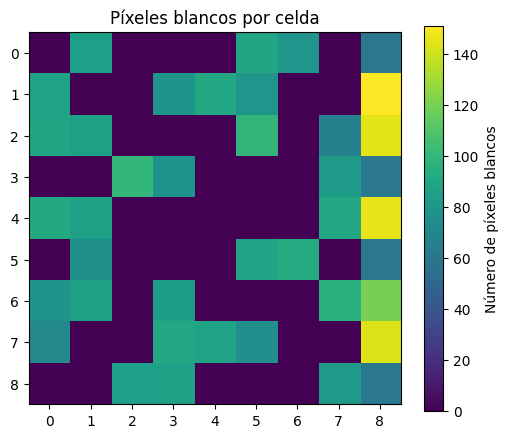

Tablero píxeles blancos por celda: outputs\white_pixel_counts.png


In [27]:
plt.figure(figsize=(6, 5))
plt.imshow(white_pixel_counts, cmap="viridis")
plt.colorbar(label="Número de píxeles blancos")
plt.title("Píxeles blancos por celda")
plt.xticks(range(9))
plt.yticks(range(9))

# Guardar conteos píxeles blancos por celda
white_pixel_counts_path = OUTPUT_DIR / "white_pixel_counts.png"
plt.savefig(white_pixel_counts_path, dpi=300, bbox_inches="tight")

plt.show()
print(f"Tablero píxeles blancos por celda: {white_pixel_counts_path}")

#### 4.1.2. Definir umbral de celda vacía

Si una celda tiene menos píxeles blancos que el umbral, se considerará vacía.

In [28]:
# Función para definir el umbral de una celda vacía

# Threshold = 65
def is_empty_cell(processed_cell, threshold=65):
    white_pixels = cv2.countNonZero(processed_cell)
    return white_pixels < threshold

### 4.2. Crear matriz de ocupación

Construir matriz de 9x9
- **0** = celda vacía
- **1** = celda con número

In [29]:
EMPTY_THRESHOLD = 65

occupancy_matrix = np.zeros((9, 9), dtype=int)

for row in range(9):
    for col in range(9):
        processed = preprocess_cell_for_digit(cells[row][col], margin=10)

        if is_empty_cell(processed, threshold=EMPTY_THRESHOLD):
            occupancy_matrix[row, col] = 0
        else:
            occupancy_matrix[row, col] = 1

occupancy_matrix

array([[0, 1, 0, 0, 0, 1, 1, 0, 0],
       [1, 0, 0, 1, 1, 1, 0, 0, 1],
       [1, 1, 0, 0, 0, 1, 0, 1, 1],
       [0, 0, 1, 1, 0, 0, 0, 1, 0],
       [1, 1, 0, 0, 0, 0, 0, 1, 1],
       [0, 1, 0, 0, 0, 1, 1, 0, 0],
       [1, 1, 0, 1, 0, 0, 0, 1, 1],
       [1, 0, 0, 1, 1, 1, 0, 0, 1],
       [0, 0, 1, 1, 0, 0, 0, 1, 0]])

#### 4.2.1. Comparar con la matriz esperada

In [30]:
# Matriz esperada
expected_occupancy = np.array([
    [0,1,0,0,0,1,1,0,0],
    [1,0,0,1,1,1,0,0,1],
    [1,1,0,0,0,1,0,1,1],
    [0,0,1,1,0,0,0,1,0],
    [1,1,0,0,0,0,0,1,1],
    [0,1,0,0,0,1,1,0,0],
    [1,1,0,1,0,0,0,1,1],
    [1,0,0,1,1,1,0,0,1],
    [0,0,1,1,0,0,0,1,0],
])

In [31]:
# Comparación
print("Umbral usado:", EMPTY_THRESHOLD)

print("Matriz detectada:")
print(occupancy_matrix)

print("\nMatriz esperada:")
print(expected_occupancy)

print("\n¿Coinciden?")
print(np.array_equal(occupancy_matrix, expected_occupancy))

Umbral usado: 65
Matriz detectada:
[[0 1 0 0 0 1 1 0 0]
 [1 0 0 1 1 1 0 0 1]
 [1 1 0 0 0 1 0 1 1]
 [0 0 1 1 0 0 0 1 0]
 [1 1 0 0 0 0 0 1 1]
 [0 1 0 0 0 1 1 0 0]
 [1 1 0 1 0 0 0 1 1]
 [1 0 0 1 1 1 0 0 1]
 [0 0 1 1 0 0 0 1 0]]

Matriz esperada:
[[0 1 0 0 0 1 1 0 0]
 [1 0 0 1 1 1 0 0 1]
 [1 1 0 0 0 1 0 1 1]
 [0 0 1 1 0 0 0 1 0]
 [1 1 0 0 0 0 0 1 1]
 [0 1 0 0 0 1 1 0 0]
 [1 1 0 1 0 0 0 1 1]
 [1 0 0 1 1 1 0 0 1]
 [0 0 1 1 0 0 0 1 0]]

¿Coinciden?
True


## 5. Preparar dígitos para MNIST

Preprocesar para que MNIST pueda reconocer bien los dígitos. Cada celda debe convertirse a:
1. Imagen ``28x28``
2. Fondo negro
3. Dígito blanco
4. Dígito centrado
5. Valores normalizados entre 0 y 1

### 5.1. Extraer el dígito de una celda

Buscar los píxeles blancos de la celda procesada. Si hay un número, calcula el rectángulo mínimo que contiene esos píxeles y recorta solo esa zona.

In [32]:
# Función para detectar la región exacta del dígito
def extract_digit_region(processed_cell):
    coords = cv2.findNonZero(processed_cell)

    if coords is None:
        return None

    x, y, w, h = cv2.boundingRect(coords)

    digit = processed_cell[y:y+h, x:x+w]

    return digit

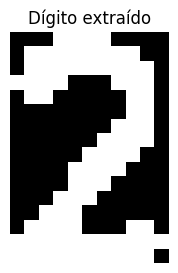

Tamaño del dígito: (16, 11)


In [33]:
# Prueba -  celda con número
processed = preprocess_cell_for_digit(cells[0][1], margin=10)
digit = extract_digit_region(processed)

plt.figure(figsize=(3, 3))
plt.imshow(digit, cmap="gray")
plt.axis("off")
plt.title("Dígito extraído")

plt.show()
print("Tamaño del dígito:", digit.shape)

### 5.2. Convertir a formato ***MNIST***

Tomar el número extraído y lo coloca centrado en una imagen ``28x28``.
1. Redimensionar para que quepa en una caja de 20x20
2. Pegarlo centrado en un lienzo negro de 28x28

#### 5.2.1. Convertir a formato MNIST

In [34]:
# Función para convertir a formato MNIST
def prepare_digit_for_mnist(processed_cell, output_size=28, digit_size=20):
    digit = extract_digit_region(processed_cell)

    if digit is None:
        return np.zeros((output_size, output_size), dtype=np.float32)

    h, w = digit.shape

    # Evitar divisiones raras
    if h == 0 or w == 0:
        return np.zeros((output_size, output_size), dtype=np.float32)

    # Mantener proporción
    scale = digit_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    digit_resized = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((output_size, output_size), dtype=np.uint8)

    x_offset = (output_size - new_w) // 2
    y_offset = (output_size - new_h) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = digit_resized

    # Normalizar a 0-1
    canvas = canvas.astype("float32") / 255.0

    return canvas

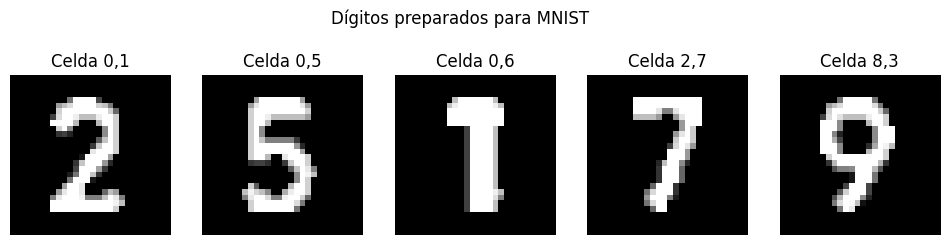

In [35]:
# Probar con varios dígitos
test_positions = [
    (0, 1),  # 2
    (0, 5),  # 5
    (0, 6),  # 1
    (2, 7),  # 7
    (8, 3),  # 9
]

fig, axes = plt.subplots(1, len(test_positions), figsize=(12, 3))

for ax, (row, col) in zip(axes, test_positions):
    processed = preprocess_cell_for_digit(cells[row][col], margin=10)
    mnist_digit = prepare_digit_for_mnist(processed)

    ax.imshow(mnist_digit, cmap="gray")
    ax.set_title(f"Celda {row},{col}")
    ax.axis("off")

plt.suptitle("Dígitos preparados para MNIST")
plt.show()

### 5.3. Preparar todos los dígitos disponibles

Recorre las 81 celdas.
- Si la celda está vacía, se queda como 0
- Si la celda contiene número, prepara para MNIST y la guarda

In [36]:
# Preparar todos los dígitos ocupados
mnist_cells = [[None for _ in range(9)] for _ in range(9)]

for row in range(9):
    for col in range(9):
        processed = preprocess_cell_for_digit(cells[row][col], margin=10)

        if is_empty_cell(processed, threshold=EMPTY_THRESHOLD):
            mnist_cells[row][col] = None
        else:
            mnist_cells[row][col] = prepare_digit_for_mnist(processed)

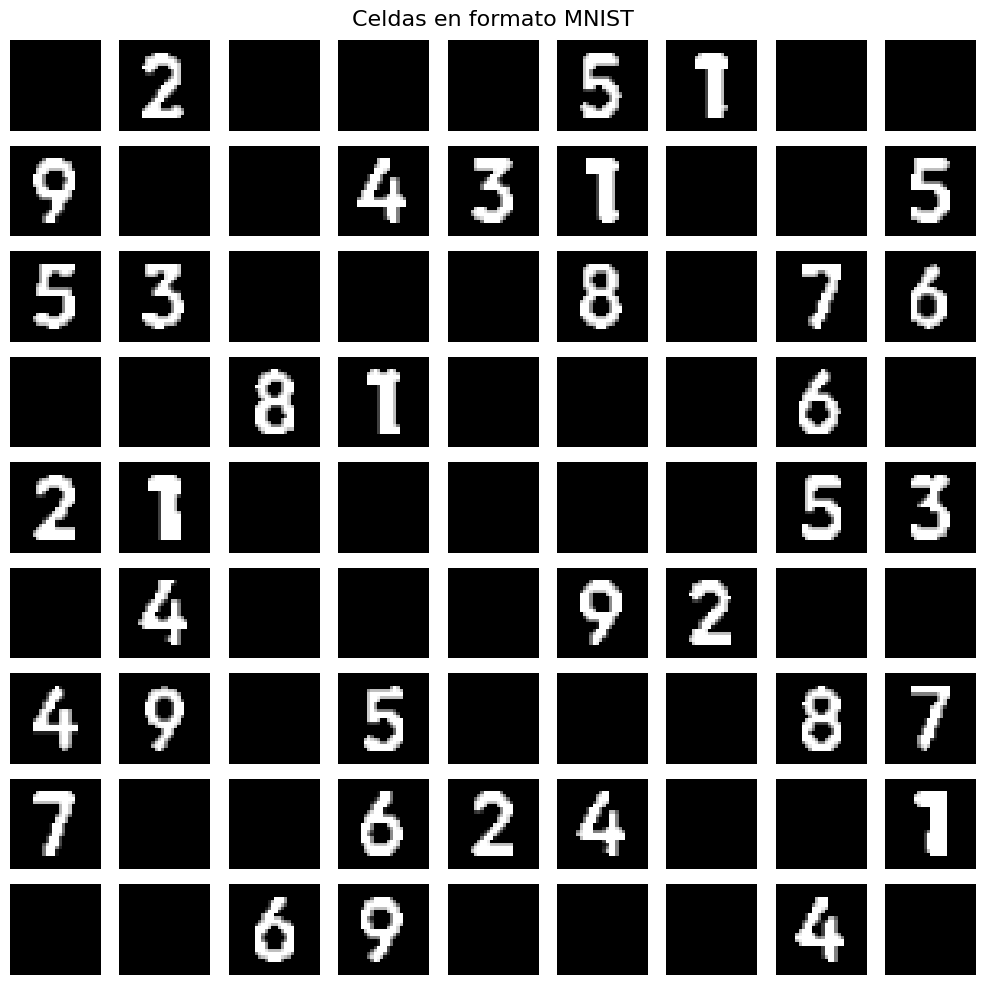

Visualización de celdas MNIST_pre guardada en: outputs\mnist_cells_pre.png


In [42]:
# Visualizar solo las celdas ocupadas
fig, axes = plt.subplots(9, 9, figsize=(10, 10))

for row in range(9):
    for col in range(9):
        ax = axes[row, col]

        if mnist_cells[row][col] is None:
            ax.imshow(np.zeros((28, 28)), cmap="gray")
        else:
            ax.imshow(mnist_cells[row][col], cmap="gray")

        ax.axis("off")

plt.suptitle("Celdas en formato MNIST", fontsize=16)
plt.tight_layout()

# Guardar celdas extraídas
mnist_cells_pre_path = OUTPUT_DIR / "mnist_cells_pre.png"
plt.savefig(mnist_cells_pre_path, dpi=300, bbox_inches="tight")

plt.show()
print(f"Visualización de celdas MNIST_pre guardada en: {mnist_cells_pre_path}")

### 5.4. Limpiar componentes pequeños o líneas de borde

Después del preprocesamiento, una celda puede tener:
- El número
- Restos de líneas del tablero
- Ruido pequeño

``connectedComponentsWithStats`` detecta “bloques” blancos separados. Usar para filtrar componentes por tamaño y forma.

#### 5.4.1. Función para limpiar componentes

In [38]:
# Función para limpiar componentes
def keep_digit_component(processed_cell, min_area=15):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        processed_cell,
        connectivity=8
    )

    cleaned = np.zeros_like(processed_cell)

    components = []

    for label in range(1, num_labels):  # 0 es el fondo
        x, y, w, h, area = stats[label]

        if area < min_area:
            continue

        # Eliminar líneas verticales/horizontales muy finas
        aspect_ratio = w / h if h > 0 else 0

        is_thin_vertical_line = w <= 3 and h > 10
        is_thin_horizontal_line = h <= 3 and w > 10

        if is_thin_vertical_line or is_thin_horizontal_line:
            continue

        components.append((label, area))

    if len(components) == 0:
        return cleaned

    # Mantener el componente de mayor área
    best_label = max(components, key=lambda item: item[1])[0]
    cleaned[labels == best_label] = 255

    return cleaned

### 5.5. Modificar preparación para ***MNIST***

In [39]:
# Modificar la función anterior "prepare_digit_for_mnist" para limpiar antes de extraer
def prepare_digit_for_mnist(processed_cell, output_size=28, digit_size=20):
    cleaned_cell = keep_digit_component(processed_cell)

    digit = extract_digit_region(cleaned_cell)

    if digit is None:
        return np.zeros((output_size, output_size), dtype=np.float32)

    h, w = digit.shape

    if h == 0 or w == 0:
        return np.zeros((output_size, output_size), dtype=np.float32)

    scale = digit_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    digit_resized = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((output_size, output_size), dtype=np.uint8)

    x_offset = (output_size - new_w) // 2
    y_offset = (output_size - new_h) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = digit_resized

    canvas = canvas.astype("float32") / 255.0

    return canvas

#### 5.5.1. Visualizar de nuevo todas las celdas

In [40]:
mnist_cells = [[None for _ in range(9)] for _ in range(9)]

for row in range(9):
    for col in range(9):
        processed = preprocess_cell_for_digit(cells[row][col], margin=10)

        if is_empty_cell(processed, threshold=EMPTY_THRESHOLD):
            mnist_cells[row][col] = None
        else:
            mnist_cells[row][col] = prepare_digit_for_mnist(processed)

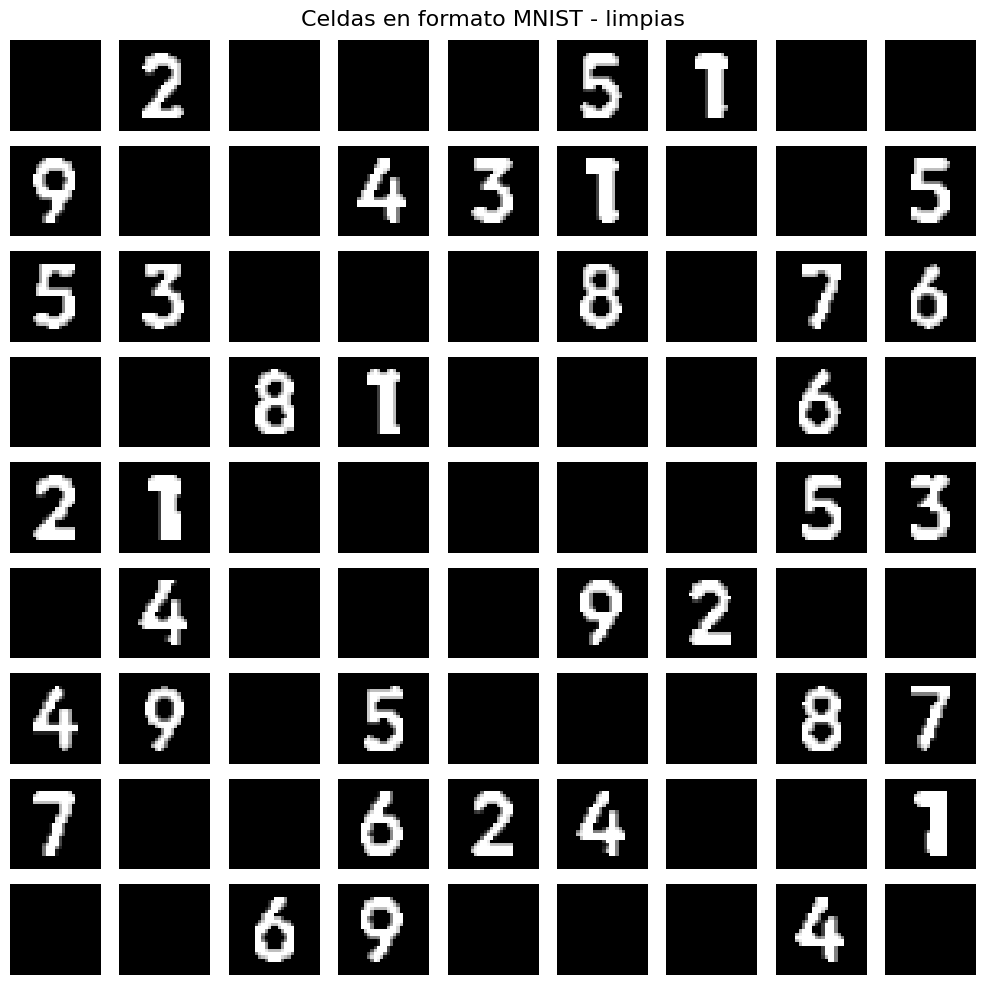

Visualización de celdas limpias MNIST guardada en: outputs\mnist_cells.png


In [43]:
fig, axes = plt.subplots(9, 9, figsize=(10, 10))

for row in range(9):
    for col in range(9):
        ax = axes[row, col]

        if mnist_cells[row][col] is None:
            ax.imshow(np.zeros((28, 28)), cmap="gray")
        else:
            ax.imshow(mnist_cells[row][col], cmap="gray")

        ax.axis("off")

plt.suptitle("Celdas en formato MNIST - limpias", fontsize=16)
plt.tight_layout()

# Guardar celdas extraídas
mnist_cells_path = OUTPUT_DIR / "mnist_cells.png"
plt.savefig(mnist_cells_path, dpi=300, bbox_inches="tight")

plt.show()
print(f"Visualización de celdas limpias MNIST guardada en: {mnist_cells_path}")